In [1]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle
import joblib
from scipy.stats import pearsonr


import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

# import imageio

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve


In [2]:
inputlength = 10
outputavgtime = 5

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
# modelfilefront = "MPI_histrecord_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

ssplist = ['245','370','585']

obstimerange = [1940,2025]
experiment_era_obs = [1960,2025]

data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [3]:
obsparams = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir,
}

AllObs = DataHolder.ERA5InputOutput(obsparams)

In [4]:
# most recent sample

climoyears = [1960,1990]
climoinds = [climoyears[0]-obstimerange[0],climoyears[1]-obstimerange[0]]

expinds = [experiment_era_obs[0]-obstimerange[0],experiment_era_obs[1]-obstimerange[0]]

device = 'mps'

allinputsst = DataHolder.stackobs(AllObs.allinput,inputlength)
allinputsst_std = allinputsst - np.mean(allinputsst,axis=1,keepdims=True)

allinputgmt = DataHolder.stackobs(AllObs.allGMT,inputlength)
allinputgmt = np.mean(allinputgmt,axis=1)
allinputgmt = allinputgmt-np.mean(AllObs.allGMT[climoinds[0]:climoinds[1]])

summer_climo = np.mean(AllObs.alloutput[climoinds[0]:climoinds[1]],axis=0)
alloutputsummer_anom = AllObs.alloutput-summer_climo
alloutputsummer_anom = DataHolder.stackobs(alloutputsummer_anom,outputavgtime)

allinputsst_std = allinputsst_std[expinds[0]:]
allinputsst_std[np.isnan(allinputsst_std)] = 0
allinputgmt = allinputgmt[expinds[0]:]

summer_climo = np.mean(AllObs.alloutput[climoinds[0]:climoinds[1]],axis=0)
alloutputsummer_anom = AllObs.alloutput-summer_climo
alloutputsummer_anom = DataHolder.stackobs(alloutputsummer_anom,outputavgtime)

maxevent = np.max(alloutputsummer_anom,axis=1)
maxevent = maxevent[(expinds[0]+inputlength):]

In [5]:
input_priorrecord_perturb = np.arange(-1, 5.1, 0.1)
n_perturb = len(input_priorrecord_perturb)
n_samples = allinputsst_std.shape[0]  # assuming first dimension is number of samples

# Create arrays with explicit (n_samples, n_perturb, ...) structure
# Then reshape to (n_samples * n_perturb, ...) for the neural net

# SST input: tile across perturbation dimension
# Shape: (n_samples, n_perturb, height, width, channels) -> (n_samples * n_perturb, height, width, channels)
inputsst_t = np.tile(allinputsst_std[:, np.newaxis], (1, n_perturb, 1, 1, 1))
inputsst_t = inputsst_t.reshape(-1, *allinputsst.shape[1:])
inputsst_t = torch.tensor(inputsst_t, dtype=torch.float32).to(device)

inputsst_climo = torch.mean(inputsst_t,axis=0)*torch.ones(inputsst_t.shape).to(device)

# GMT input: tile across perturbation dimension
# Shape: (n_samples, n_perturb, 1) -> (n_samples * n_perturb, 1)
inputGMT_t = np.repeat(allinputgmt[:, np.newaxis], n_perturb, axis=0)
inputGMT_t = torch.tensor(inputGMT_t, dtype=torch.float32)

# Prior record perturbations: broadcast across samples
# Shape: (n_samples, n_perturb, 1) -> (n_samples * n_perturb, 1)
input_priorrecord_perturb_t = np.tile(input_priorrecord_perturb[np.newaxis, :, np.newaxis], (n_samples, 1, 1))
input_priorrecord_perturb_t = input_priorrecord_perturb_t.reshape(-1, 1)
input_priorrecord_perturb_t = torch.tensor(input_priorrecord_perturb_t, dtype=torch.float32)

# Concatenate
inputvecs_t = torch.cat((inputGMT_t, input_priorrecord_perturb_t), axis=1).to(device)

In [6]:
n_best = 3

obspredall = np.empty((n_best,n_samples*len(input_priorrecord_perturb),18,36,))+np.nan
obspred_climo = np.empty((n_best,n_samples*len(input_priorrecord_perturb),18,36,))+np.nan

for ilat,lat in enumerate(AllObs.output_lat):

    for ilon,lon in enumerate(AllObs.output_lon):

        metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed*.json"
        filelist = glob.glob(metricsout)

        if len(filelist)!=0:
            # print('models exist, proceeding')

            bestseeds = helpers.get_best_files(filelist,n_best)

            for iseed,seed in enumerate(bestseeds):
                # load the model

                loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed_"+str(seed)+".pt"
                cnn = buildmodel.CNNclassifier(inputsst_climo, inputvecs_t, 2).to('cpu')
                cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
                cnn.to(device)

                with torch.no_grad():
                    cnn.eval()
                    obspred = cnn(inputsst_t, inputvecs_t).cpu().numpy()
                    obspredclimo = cnn(inputsst_climo, inputvecs_t).cpu().numpy()

                obspredall[iseed,:,ilat,ilon] = obspred[:,1]
                obspred_climo[iseed,:,ilat,ilon] = obspredclimo[:,1]



In [7]:
meanobspred = np.mean(obspredall,axis=0)
meanobspred = np.reshape(meanobspred,(n_samples,n_perturb,meanobspred.shape[1],meanobspred.shape[2]))

meanobspredclimo = np.mean(obspred_climo,axis=0)
meanobspredclimo = np.reshape(meanobspredclimo,(n_samples,n_perturb,meanobspredclimo.shape[1],meanobspredclimo.shape[2]))

In [8]:
def closest_to_per(mat,per):

    matdiff = np.abs(mat-per)
    matmin = np.argmin(matdiff,axis=0)

    return matmin

percentiles = np.arange(0,1.01,0.01)

obs_minevent_qconf = np.empty((n_samples,18,36,len(percentiles)))
obs_minevent_qconf_climo = np.empty((n_samples,18,36,len(percentiles)))

for iper, per in enumerate(percentiles):

    for itime in range(n_samples):

        predsel = meanobspred[itime,:,:,]
        obs_qconf = closest_to_per(predsel,per)

        climopredsel = meanobspredclimo[itime]
        obs_qconf_climo = closest_to_per(climopredsel,per)

        for ilat in range(18):
            for ilon in range(36):

                obs_minevent_qconf[itime,ilat,ilon,iper] = input_priorrecord_perturb[obs_qconf[ilat,ilon]]
                obs_minevent_qconf_climo[itime,ilat,ilon,iper] = input_priorrecord_perturb[obs_qconf_climo[ilat,ilon]]

                

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_91578/1885948427.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma_r')


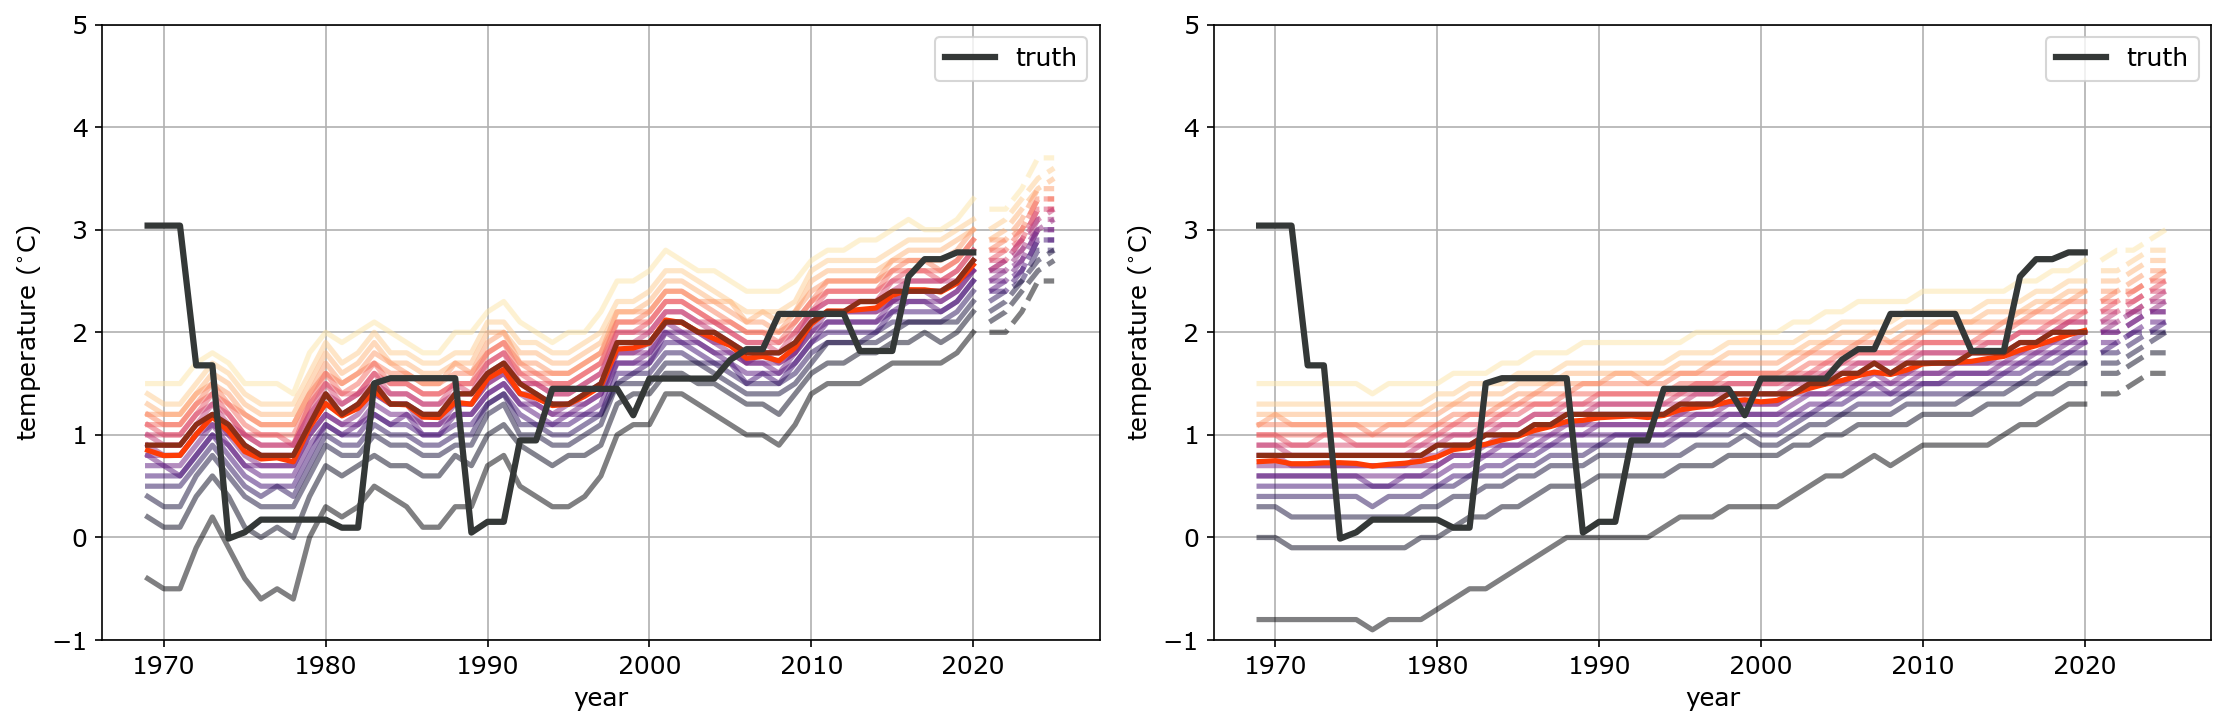

In [60]:
xvec1 = np.arange(1969,2026)
xvec2 = np.arange(1969,2026-outputavgtime)

# plt.fill_between(xvec1,obs_minevent_qconf[13,24,:,5],obs_minevent_qconf[13,24,:,-5],color='xkcd:golden rod',alpha=0.4)
cmap = cm.get_cmap('magma_r')
n_lines = 20
colors = cmap(np.linspace(0, 1, n_lines))

latsel = 15
lonsel = 3

outputsummertemp = (AllObs.alloutput-summer_climo)[(expinds[0]+inputlength):,latsel,lonsel]

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

for iplot in range(1, 20):
    plt.plot(xvec2, obs_minevent_qconf[:len(xvec2), latsel, lonsel, 5*iplot], 
             color=colors[iplot],linewidth=2.5,alpha=0.5)
    
    plt.plot(xvec1[len(xvec2):], obs_minevent_qconf[len(xvec2):, latsel, lonsel, 5*iplot], 
            color=colors[iplot],linewidth=2.5,alpha=0.5,linestyle='--')

plt.plot(xvec2,np.mean(obs_minevent_qconf[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red orange',linewidth=2.5)
plt.plot(xvec2,np.median(obs_minevent_qconf[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red brown',linewidth=2.5)

plt.plot(xvec2 ,maxevent[:,latsel,lonsel],color='xkcd:charcoal',linewidth=3,label='truth')

plt.legend()
plt.ylabel(r'temperature ($^{\circ}$C)')
plt.xlabel('year')

plt.grid()
plt.ylim(-1,5)

plt.subplot(1,2,2)
for iplot in range(1, 20):
    plt.plot(xvec2, obs_minevent_qconf_climo[:len(xvec2), latsel, lonsel, 5*iplot], 
             color=colors[iplot],linewidth=2.5,alpha=0.5)
    
    plt.plot(xvec1[len(xvec2):], obs_minevent_qconf_climo[len(xvec2):, latsel, lonsel, 5*iplot], 
            color=colors[iplot],linewidth=2.5,alpha=0.5,linestyle='--')

plt.plot(xvec2,np.mean(obs_minevent_qconf_climo[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red orange',linewidth=2.5)
plt.plot(xvec2,np.median(obs_minevent_qconf_climo[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red brown',linewidth=2.5)

plt.plot(xvec2,maxevent[:,latsel,lonsel],color='xkcd:charcoal',linewidth=3,label='truth')

plt.legend()
plt.ylabel(r'temperature ($^{\circ}$C)')
plt.xlabel('year')

plt.ylim(-1,5)
plt.grid()
plt.tight_layout()


In [10]:
exceedencemat = np.empty((18,36,len(percentiles)))
exceedencemat_climo = np.empty((18,36,len(percentiles)))

for iper,per in enumerate(percentiles):

    n_exceedences = maxevent>obs_minevent_qconf[:maxevent.shape[0],:,:,iper]
    exceedencemat[:,:,iper] = np.mean(1*n_exceedences,axis=0)

    n_exceedences_climo = maxevent>obs_minevent_qconf_climo[:maxevent.shape[0],:,:,iper]
    exceedencemat_climo[:,:,iper] = np.mean(1*n_exceedences_climo,axis=0)

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_91578/4079947967.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


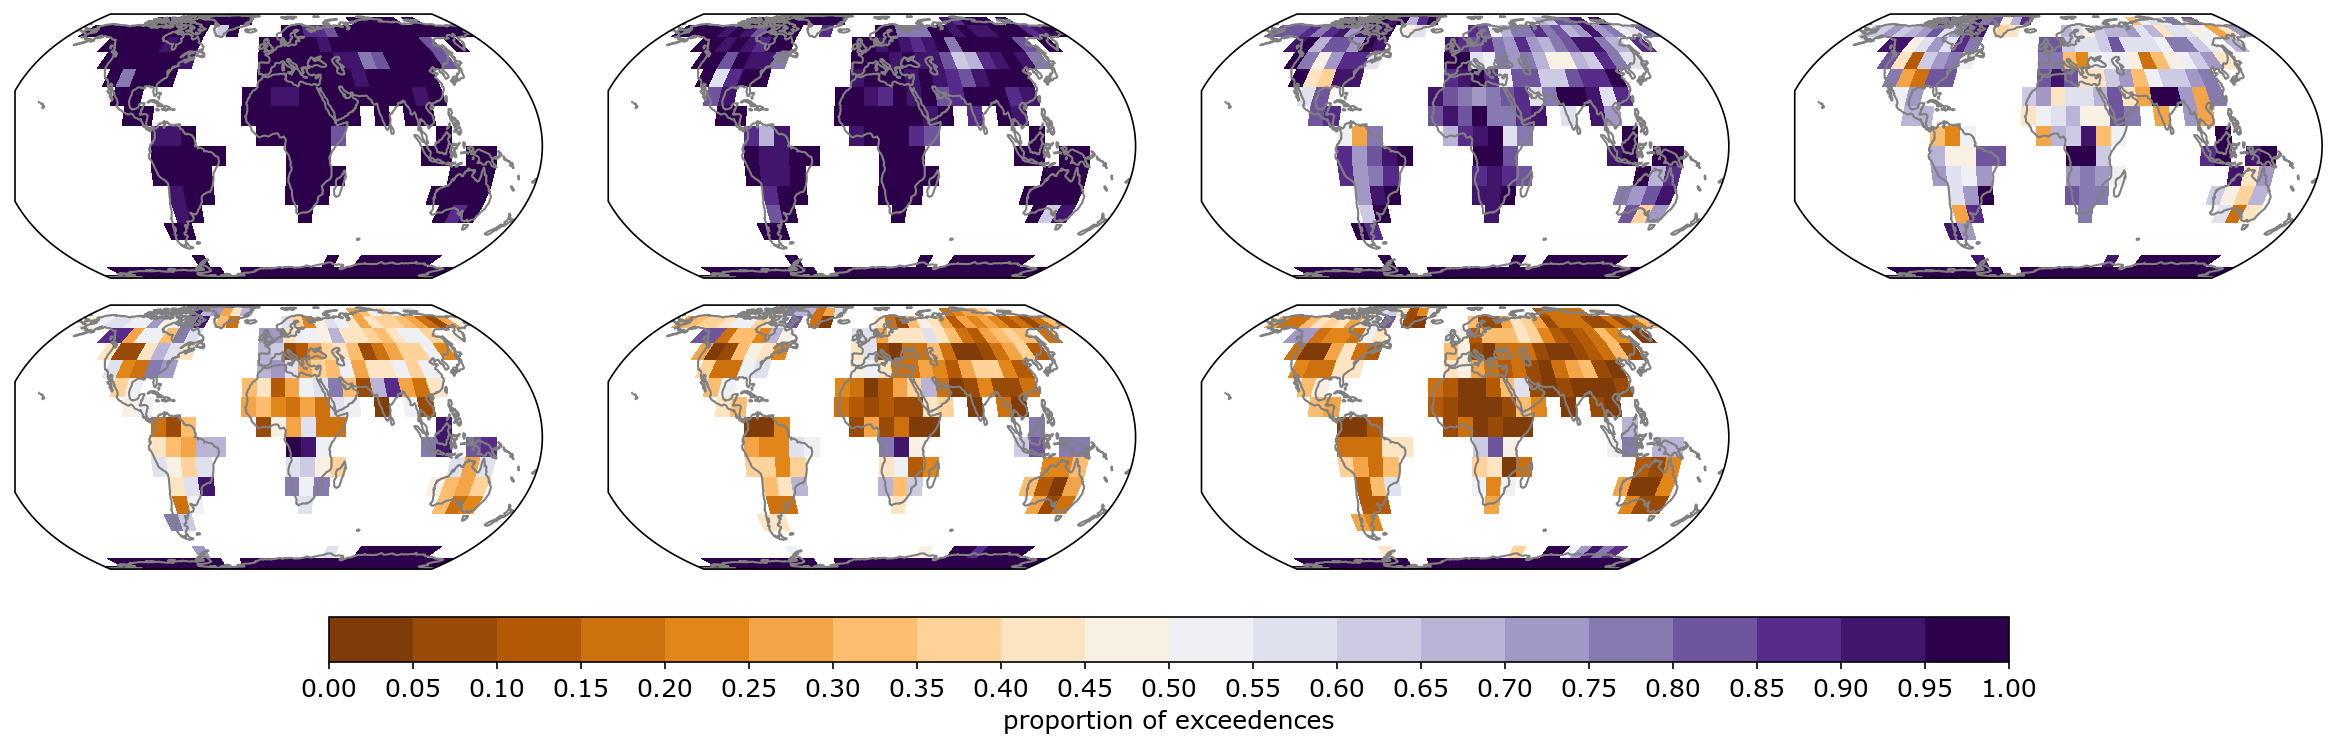

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_91578/4079947967.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


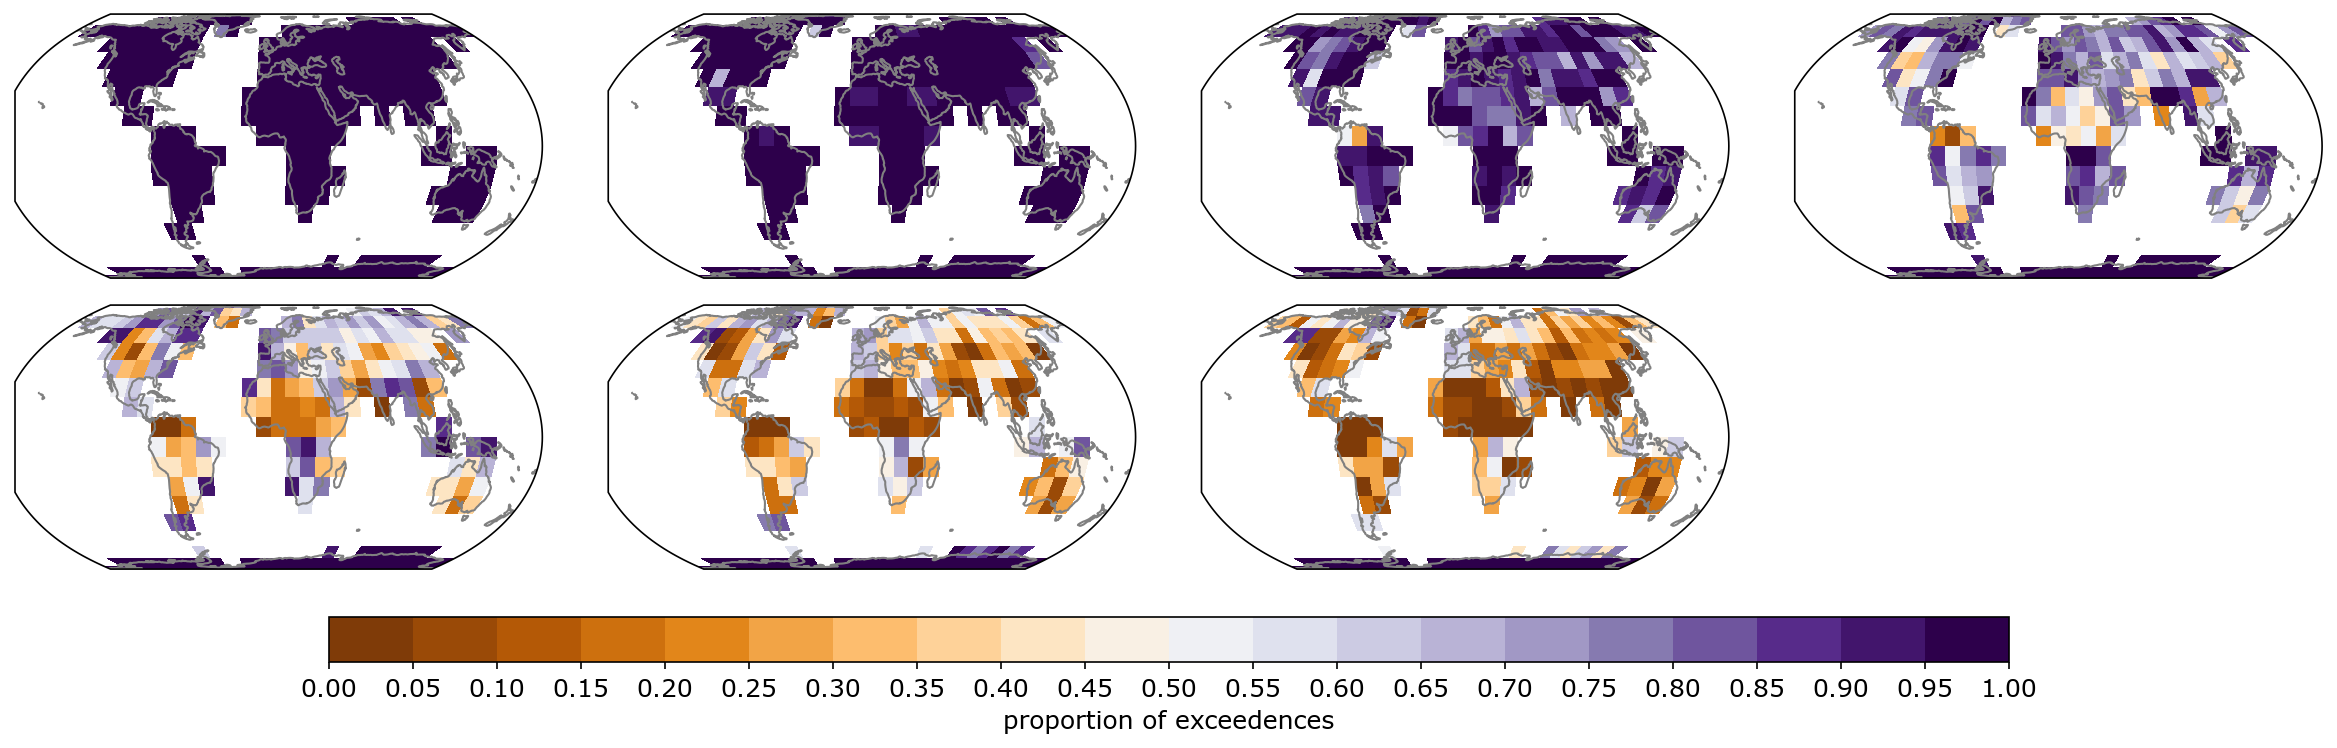

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_91578/4079947967.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


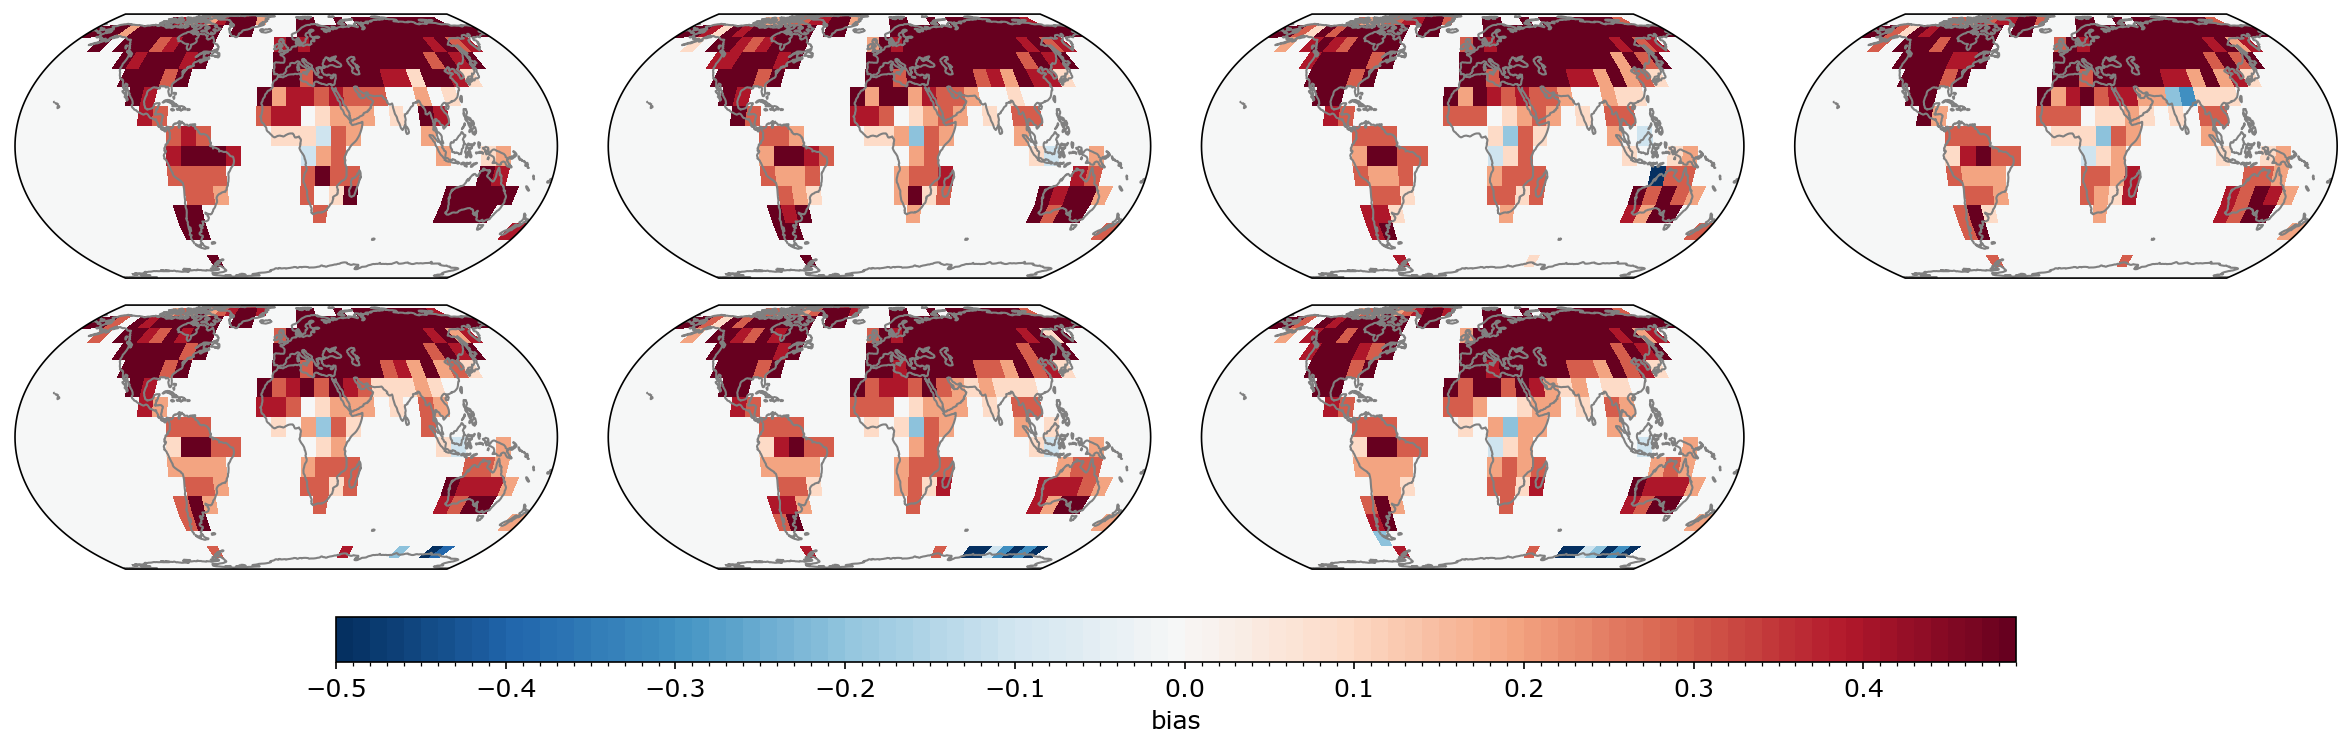

In [11]:
persel = np.flipud(np.array([5,10,25,50,75,90,95]))

oceanmask = np.isnan(AllObs.alloutput[-1])
exceedencemat[oceanmask] = np.nan
exceedencemat_climo[oceanmask] = np.nan

bounds = np.arange(0, 1.05, .05)
norm = mcolors.BoundaryNorm(bounds, 256)

plt.figure(figsize=(16,6))

for iper,per in enumerate(persel):

    ax = plt.subplot(3,4,iper+1,projection=ccrs.EqualEarth())
    c0=ax.pcolormesh(AllObs.output_lon+5,AllObs.output_lat+5,exceedencemat[:,:,per],transform=ccrs.PlateCarree(),norm=norm,cmap='PuOr')
    ax.coastlines(color='grey')

# Add horizontal colorbar at the bottom
cbar_ax = plt.gcf().add_axes([0.15, 0.25, 0.7, 0.05])  # [left, bottom, width, height]
cbar = plt.colorbar(c0, cax=cbar_ax, orientation='horizontal', 
                    boundaries=bounds, ticks=bounds)
cbar.set_label('proportion of exceedences', fontsize=12)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16,6))

for iper,per in enumerate(persel):

    ax = plt.subplot(3,4,iper+1,projection=ccrs.EqualEarth())
    c0=ax.pcolormesh(AllObs.output_lon+5,AllObs.output_lat+5,exceedencemat_climo[:,:,per],transform=ccrs.PlateCarree(),norm=norm,cmap='PuOr')
    ax.coastlines(color='grey')

# Add horizontal colorbar at the bottom
cbar_ax = plt.gcf().add_axes([0.15, 0.25, 0.7, 0.05])  # [left, bottom, width, height]
cbar = plt.colorbar(c0, cax=cbar_ax, orientation='horizontal', 
                    boundaries=bounds, ticks=bounds)
cbar.set_label('proportion of exceedences', fontsize=12)

plt.tight_layout()
plt.show()

bounds = np.arange(-0.5, 0.5, .01)
norm = mcolors.BoundaryNorm(bounds, 256)

plt.figure(figsize=(16,6))

for iper,per in enumerate(persel):

    ax = plt.subplot(3,4,iper+1,projection=ccrs.EqualEarth())
    c0=ax.pcolormesh(AllObs.output_lon+5,AllObs.output_lat+5,obs_minevent_qconf[-1,:,:,per]-obs_minevent_qconf_climo[-1,:,:,per],transform=
                     ccrs.PlateCarree(),norm=norm,cmap='RdBu_r')
    ax.coastlines(color='grey')

# Add horizontal colorbar at the bottom
cbar_ax = plt.gcf().add_axes([0.15, 0.25, 0.7, 0.05])  # [left, bottom, width, height]
cbar = plt.colorbar(c0, cax=cbar_ax, orientation='horizontal', 
                    boundaries=bounds, )
cbar.set_label('bias', fontsize=12)

plt.tight_layout()


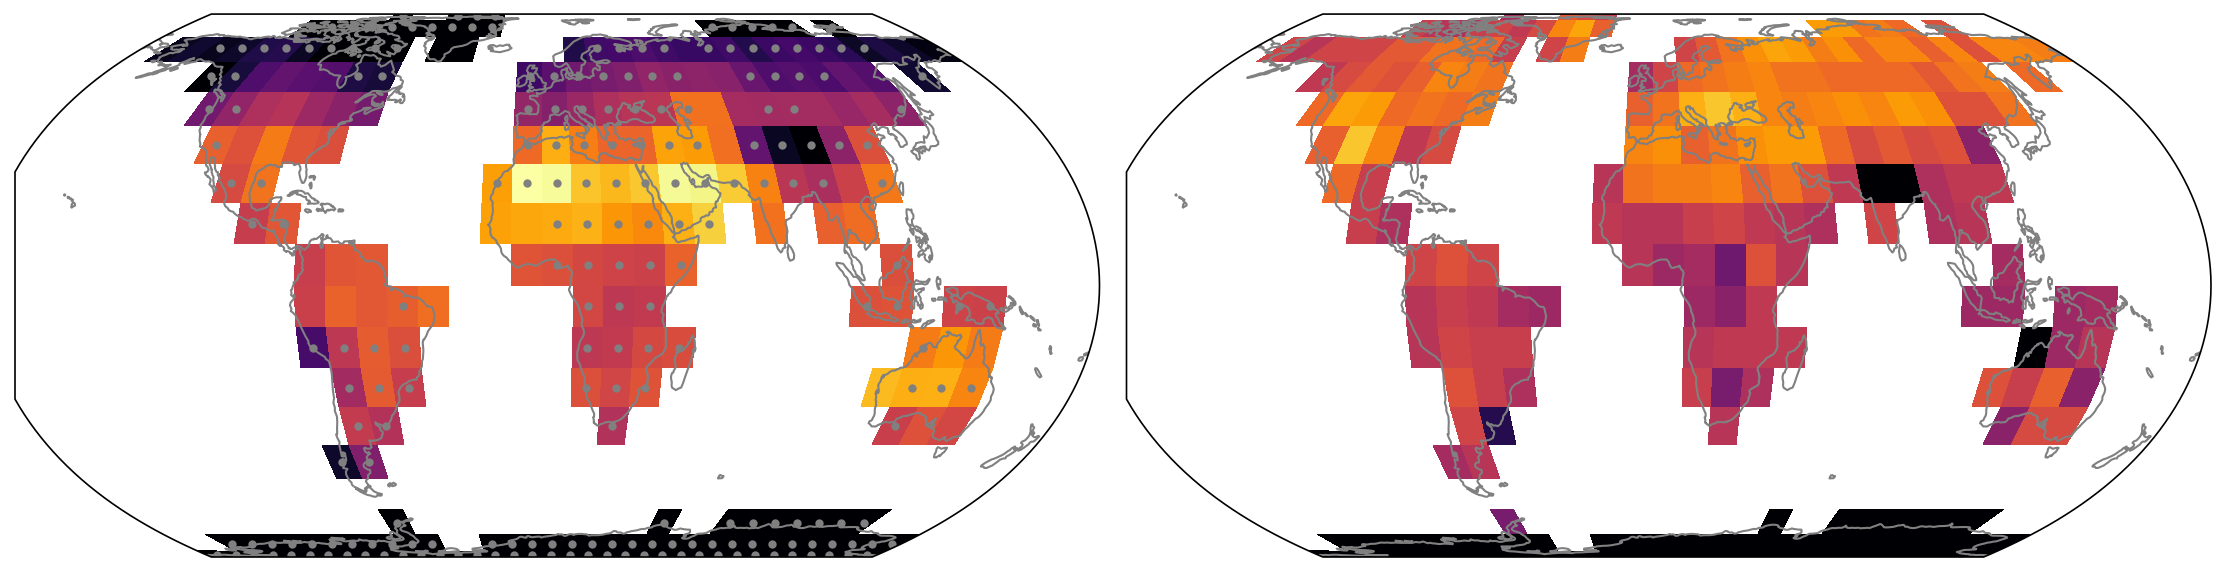

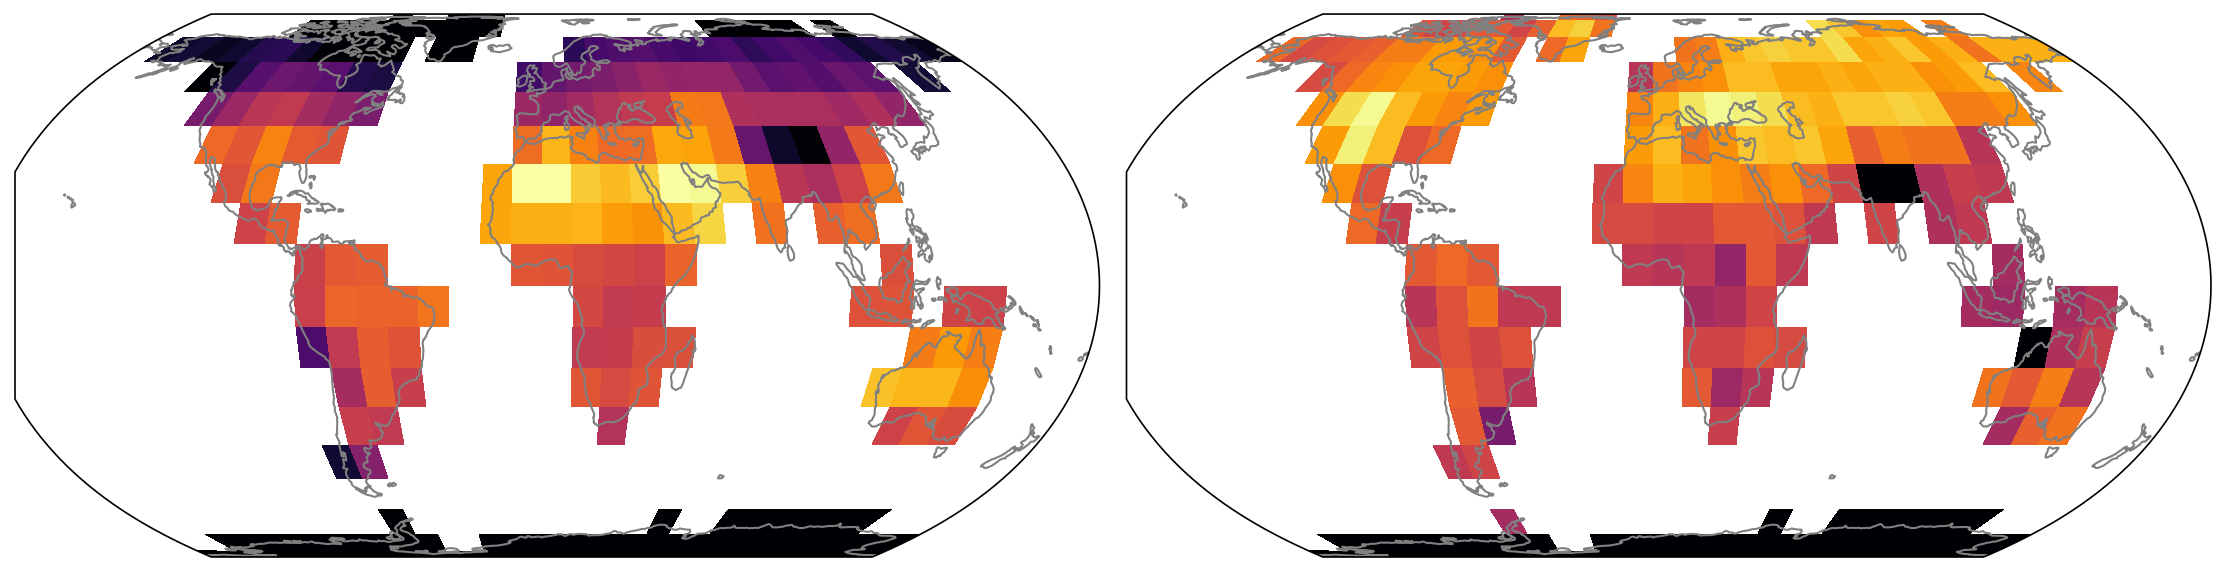

In [59]:
yearsel1 = -5
qsel = 25

lonmesh,latmesh = np.meshgrid(AllObs.output_lon+5,AllObs.output_lat+5)
lonsig = lonmesh[maxevent[-1]>obs_minevent_qconf[yearsel1,:,:,100-qsel]]
latsig = latmesh[maxevent[-1]>obs_minevent_qconf[yearsel1,:,:,100-qsel]]

obs_minevent_qconf[:,np.isnan(summer_climo)] = np.nan

plt.figure(figsize=(15,6))

ax1 = plt.subplot(1,2,1,projection=ccrs.EqualEarth())
ax1.pcolormesh(AllObs.output_lon+5,AllObs.output_lat+5,obs_minevent_qconf[yearsel1,:,:,90]+summer_climo-273.15,vmin=10,vmax=36,transform=ccrs.PlateCarree(),cmap='inferno')
ax1.scatter(lonsig,latsig,marker='.',color='grey',transform=ccrs.PlateCarree())
ax1.coastlines(color='gray')

ax1 = plt.subplot(1,2,2,projection=ccrs.EqualEarth())
ax1.pcolormesh(AllObs.output_lon+5,AllObs.output_lat+5,obs_minevent_qconf[yearsel1,:,:,90],vmin=-1,vmax=3.5,transform=ccrs.PlateCarree(),cmap='inferno')
ax1.coastlines(color='gray')

plt.tight_layout()

yearsel1 = -1
qsel = 5

obs_minevent_qconf[:,np.isnan(summer_climo)] = np.nan

plt.figure(figsize=(15,6))

ax1 = plt.subplot(1,2,1,projection=ccrs.EqualEarth())
ax1.pcolormesh(AllObs.output_lon+5,AllObs.output_lat+5,obs_minevent_qconf[yearsel1,:,:,90]+summer_climo-273.15,vmin=10,vmax=36,transform=ccrs.PlateCarree(),cmap='inferno')
ax1.coastlines(color='gray')

ax1 = plt.subplot(1,2,2,projection=ccrs.EqualEarth())
ax1.pcolormesh(AllObs.output_lon+5,AllObs.output_lat+5,obs_minevent_qconf[yearsel1,:,:,90],vmin=-1,vmax=3.5,transform=ccrs.PlateCarree(),cmap='inferno')
ax1.coastlines(color='gray')

plt.tight_layout()

In [51]:
len(latsig)

177

In [53]:
latcount = latmesh[~np.isnan(summer_climo)]

In [55]:
latcount = latcount[latcount>-70]
len(latcount)

203

In [56]:
177/203

0.8719211822660099

In [12]:
AllMPI = DataHolder.MPIInputOutput_SSPlist(obsparams,ssplist)

MPIsummerstack = DataHolder.stackmatalongdim1(AllMPI.alloutput[1],outputavgtime)
MPImaxtimeseries = np.max(MPIsummerstack,axis=2)

MPImaxtimeseries_chop = MPImaxtimeseries[:,60+inputlength-1:126]
MPImaxtimeseries_chop = MPImaxtimeseries_chop-np.mean(MPImaxtimeseries[:,60:90],axis=1,keepdims=True)

MPIsummerpercentiles = np.empty(MPImaxtimeseries_chop.shape)

for i in range(MPImaxtimeseries_chop.shape[1]):

    MPIsummerpercentiles[:,i] = np.sort(MPImaxtimeseries_chop[:,i],axis=0)

MPIsummerpercentiles = np.flipud(MPIsummerpercentiles)

data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_91578/54311228.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma_r')


(-2.0, 5.0)

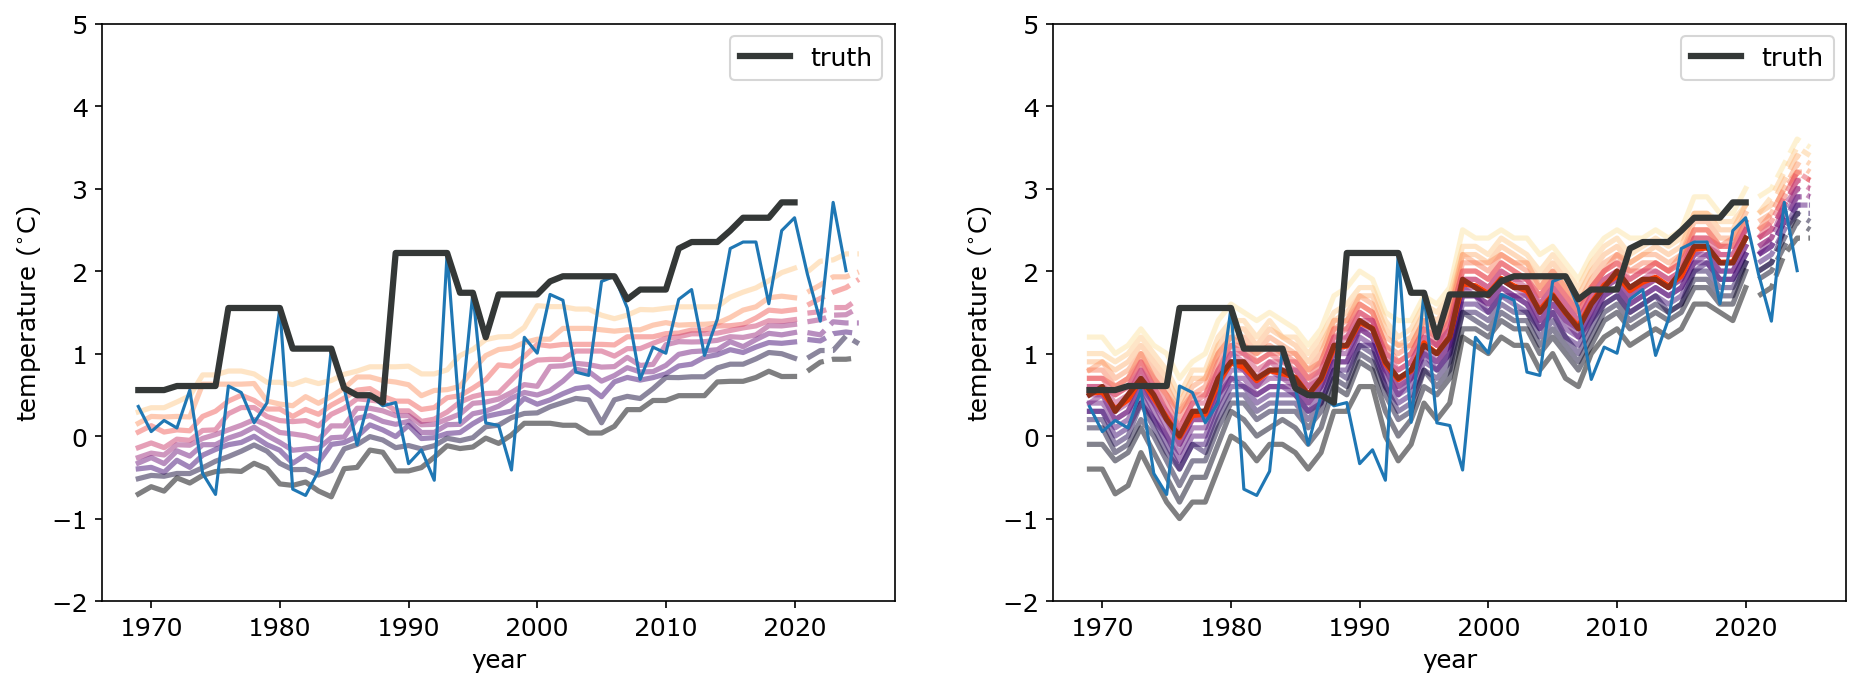

In [13]:
xvec1 = np.arange(1969,2026)
xvec2 = np.arange(1969,2026-outputavgtime)

cmap = cm.get_cmap('magma_r')
n_lines = 10
colors = cmap(np.linspace(0, 1, n_lines))

latsel = 12
lonsel = 24

outputsummertemp = (AllObs.alloutput-summer_climo)[(expinds[0]+inputlength):,latsel,lonsel]

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

for iplot in range(1, 10):
    plt.plot(xvec2, MPIsummerpercentiles[ 5*iplot,:len(xvec2), latsel, lonsel,], 
             color=colors[iplot],linewidth=2.5,alpha=0.5)
    
    plt.plot(xvec1[len(xvec2):], MPIsummerpercentiles[ 5*iplot,len(xvec2):, latsel, lonsel,], 
            color=colors[iplot],linewidth=2.5,alpha=0.5,linestyle='--')

# plt.plot(xvec2,np.mean(obs_minevent_qconf[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red orange',linewidth=2.5)
# plt.plot(xvec2,np.median(obs_minevent_qconf[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red brown',linewidth=2.5)
plt.plot(xvec1[:-1],outputsummertemp)

plt.plot(xvec2 ,maxevent[:,latsel,lonsel],color='xkcd:charcoal',linewidth=3,label='truth')

plt.legend()
plt.ylabel(r'temperature ($^{\circ}$C)')
plt.xlabel('year')
plt.ylim(-2,5)

n_lines = 20
colors = cmap(np.linspace(0, 1, n_lines))

plt.subplot(1,2,2)

for iplot in range(1, 20):
    plt.plot(xvec2, obs_minevent_qconf[:len(xvec2), latsel, lonsel, 5*iplot], 
             color=colors[iplot],linewidth=2.5,alpha=0.5)
    
    plt.plot(xvec1[len(xvec2):], obs_minevent_qconf[len(xvec2):, latsel, lonsel, 5*iplot], 
            color=colors[iplot],linewidth=2.5,alpha=0.5,linestyle='--')

plt.plot(xvec2,np.mean(obs_minevent_qconf[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red orange',linewidth=2.5)
plt.plot(xvec2,np.median(obs_minevent_qconf[:len(xvec2), latsel, lonsel, ],axis=-1),color='xkcd:red brown',linewidth=2.5)
plt.plot(xvec1[:-1],outputsummertemp)

plt.plot(xvec2 ,maxevent[:,latsel,lonsel],color='xkcd:charcoal',linewidth=3,label='truth')

plt.legend()
plt.ylabel(r'temperature ($^{\circ}$C)')
plt.xlabel('year')
plt.ylim(-2,5)